### Task 34: Deep Learning with TensorFlow/Keras

In this task, I will use TensorFlow and Keras to build an Artificial Neural Network (ANN) for a regression task. The steps include:

1. **Setup**: Import necessary libraries.
2. **Data Preparation**: Load and preprocess the dataset.
3. **Model Creation**: Define and build the ANN architecture.
4. **Compile and Train**: Compile the model and train it on the data.
5. **Evaluate**: Assess the model's performance on tes mentation.
al-network-in-tensorflow/)


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import numpy as np


In [20]:
#  synthetic data
np.random.seed(42)
X = np.random.rand(100, 1)
y = 3 * X.squeeze() + 2 + np.random.randn(100) * 0.05

#  testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
# Initialize  the model
model = Sequential()

# Add layers 
model.add(Dense(10, input_dim=1, activation='relu'))  # Hidden layer
model.add(Dense(1))  # Output layer

# Compile
model.compile(optimizer='adam', loss='mean_squared_error')

# Print summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 10)                  │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train the model
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), verbose=1)


Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 253ms/step - loss: 15.1811 - val_loss: 15.3117
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 14.5581 - val_loss: 15.1686
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 14.6642 - val_loss: 15.0277
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 14.8017 - val_loss: 14.8895
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 14.7091 - val_loss: 14.7539
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 14.0374 - val_loss: 14.6209
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 14.1097 - val_loss: 14.4909
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 13.9607 - val_loss: 14.3633
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 14.3011 - val_loss: 14.2379
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 13.4938 - val_loss: 14.1153
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 13.5696 - val_loss: 13.9952
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step 

In [18]:
# Evaluate
test_loss = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 6.5560
Test Loss: 6.555999755859375


In [21]:
#predictions
predictions = model.predict(X_test)
 
print(predictions[:5])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
[[-0.01563701]
 [-0.22015092]
 [-0.1899924 ]
 [-0.16299775]
 [-0.06366664]]


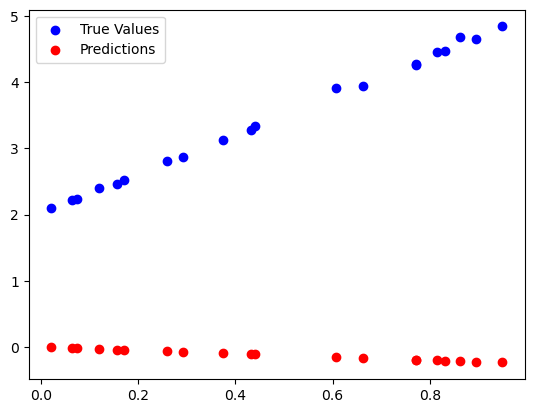

In [22]:
import matplotlib.pyplot as plt

# Plot predictions against the true values
plt.scatter(X_test, y_test, color='blue', label='True Values')
plt.scatter(X_test, predictions, color='red', label='Predictions')
plt.legend()
plt.show()
